In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


=== First 5 Rows ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== Dataset Shape ===
Rows: 150, Columns: 5

=== Data Types ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== Summary Statistics ===
        sepal_length  sepal_width  petal_length  petal_width species
count     150.000000   150.000000    150.000000   150.000000     150
unique           NaN          NaN           NaN          NaN       3
top              NaN          NaN 

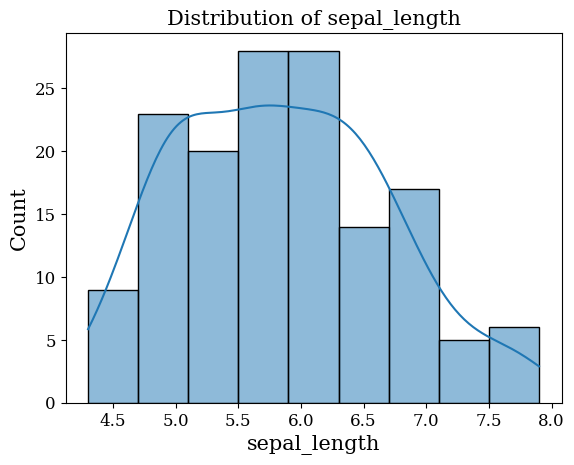

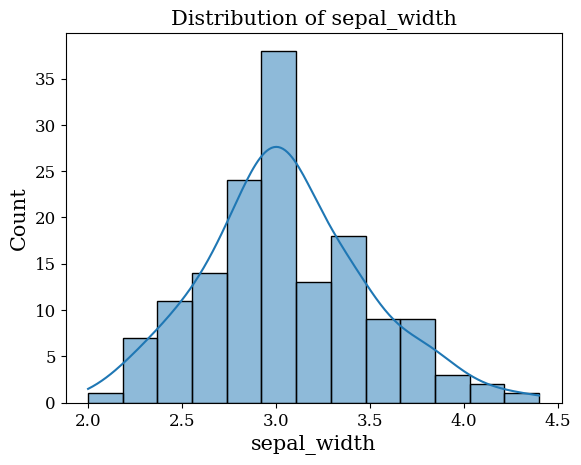

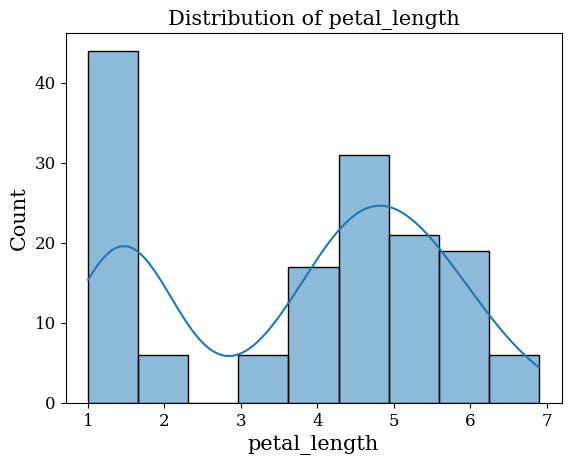

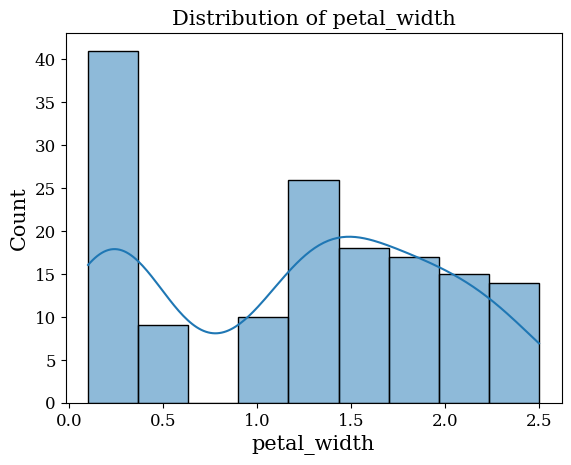

In [15]:
df = pd.read_csv("DataSet/iris/iris.csv")
perform_eda(df, target_column="species")

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def perform_eda(data, target_column=None, save_plots=False):
    print("=== First 5 Rows ===")
    print(data.head())

    print("\n=== Dataset Shape ===")
    print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

    print("\n=== Data Types ===")
    print(data.dtypes)

    print("\n=== Missing Values ===")
    print(data.isnull().sum())

    print("\n=== Summary Statistics ===")
    print(data.describe(include='all'))

    numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        plt.figure()
        sns.histplot(data[col], kde=True)
        plt.title(f"Distribution of {col}")
        if save_plots:
            plt.savefig(f"{col}_hist.png")
        plt.show()

    categorical_cols = data.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        plt.figure()
        sns.countplot(data=data, x=col)
        plt.title(f"Count of {col}")
        plt.xticks(rotation=45)
        if save_plots:
            plt.savefig(f"{col}_count.png")
        plt.show()

    if len(numerical_cols) > 1:
        plt.figure(figsize=(10, 6))
        sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        if save_plots:
            plt.savefig("correlation_heatmap.png")
        plt.show()

    for col in numerical_cols:
        plt.figure()
        sns.boxplot(data=data, x=col)
        plt.title(f"Box Plot of {col}")
        if save_plots:
            plt.savefig(f"{col}_boxplot.png")
        plt.show()

    if target_column in data.columns:
        plt.figure()
        sns.countplot(data=data, x=target_column)
        plt.title(f"Class Distribution of {target_column}")
        plt.xticks(rotation=45)
        if save_plots:
            plt.savefig(f"{target_column}_class_distribution.png")
        plt.show()